In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
!pip install -q streamlit


TensorFlow version: 2.20.0
GPU available: []


Train: (54000, 28, 28, 1) Val: (6000, 28, 28, 1) Test: (10000, 28, 28, 1)


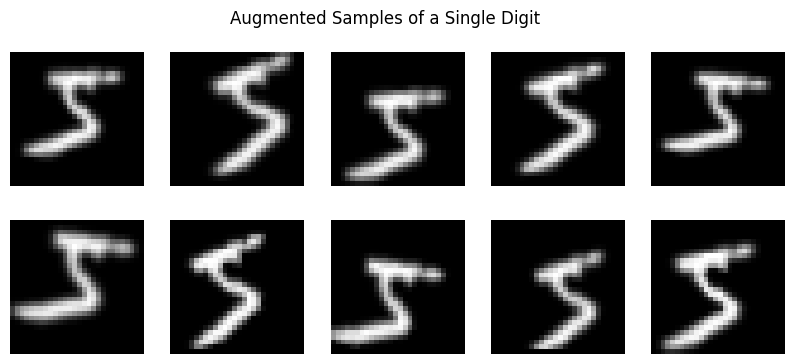

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

# Load and preprocess
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train_full = (x_train_full / 255.0).astype("float32")[..., np.newaxis]
x_test = (x_test / 255.0).astype("float32")[..., np.newaxis]

# Train / validation split
x_train, y_train = x_train_full[:54000], y_train_full[:54000]
x_val, y_val = x_train_full[54000:], y_train_full[54000:]
print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

# Image augmentation layers (active only during training)
augmentation = models.Sequential([
    layers.RandomRotation(0.05, fill_mode="constant"),          # about ±18 degrees
    layers.RandomTranslation(0.1, 0.1, fill_mode="constant"),   # ±10% shift
    layers.RandomZoom(0.1, fill_mode="constant"),               # ±10% zoom
], name="augmentation")

# Visualize augmentation
plt.figure(figsize=(10, 4))
for i in range(10):
    aug_img = augmentation(x_train[:1], training=True)[0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(aug_img.numpy().squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Augmented Samples of a Single Digit")
plt.show()

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    augmentation,
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=cbs
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.8020 - loss: 0.6149 - val_accuracy: 0.9560 - val_loss: 0.1430 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8946 - loss: 0.3343 - val_accuracy: 0.9693 - val_loss: 0.1014 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9125 - loss: 0.2773 - val_accuracy: 0.9677 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.9203 - loss: 0.2495 - val_accuracy: 0.9717 - val_loss: 0.0902 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9265 - loss: 0.2305 - val_accuracy: 0.9733 - val_loss: 0.0882 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9329 - loss: 0.2137 - val_accuracy: 0.9732 - val_loss: 0.0969 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9371 - l


--> Test Accuracy: 98.85%
--> Test Loss: 0.0369


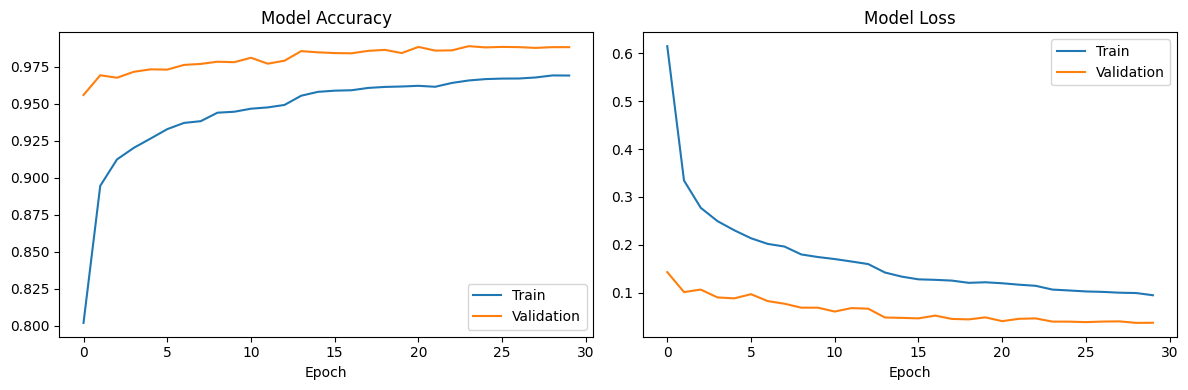

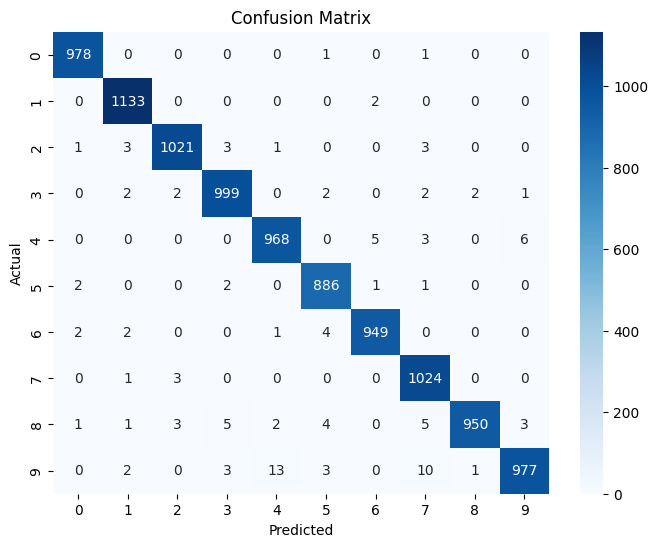

              precision    recall  f1-score   support

           0     0.9939    0.9980    0.9959       980
           1     0.9904    0.9982    0.9943      1135
           2     0.9922    0.9893    0.9908      1032
           3     0.9872    0.9891    0.9881      1010
           4     0.9827    0.9857    0.9842       982
           5     0.9844    0.9933    0.9888       892
           6     0.9916    0.9906    0.9911       958
           7     0.9762    0.9961    0.9860      1028
           8     0.9969    0.9754    0.9860       974
           9     0.9899    0.9683    0.9790      1009

    accuracy                         0.9885     10000
   macro avg     0.9885    0.9884    0.9884     10000
weighted avg     0.9885    0.9885    0.9885     10000

--> Model saved as digit_ann.keras


In [ ]:
# Test evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n--> Test Accuracy: {test_acc * 100:.2f}%")
print(f"--> Test Loss: {test_loss:.4f}")

# Accuracy and loss curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["accuracy"], label="Train")
ax[0].plot(history.history["val_accuracy"], label="Validation")
ax[0].set_title("Model Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(history.history["loss"], label="Train")
ax[1].plot(history.history["val_loss"], label="Validation")
ax[1].set_title("Model Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.tight_layout()
plt.show()

# Confusion matrix and classification report
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, digits=4))

# Save model
model.save("digit_ann.keras")
print("--> Model saved as digit_ann.keras")

In [ ]:
import os, zipfile
from PIL import Image
from scipy.ndimage import rotate, shift
from google.colab import files

os.makedirs("sample_inputs", exist_ok=True)

def save(arr28, name):
    img = Image.fromarray((255 - arr28 * 255).astype("uint8")).resize((280, 280), Image.LANCZOS)
    img.save(f"sample_inputs/{name}")

# Test case 1: clean digit
i = int(np.where(y_test == 7)[0][0])
save(x_test[i].squeeze(), "test1_clean_digit_7.png")

# Test case 2: rotated + shifted digit
j = int(np.where(y_test == 3)[0][0])
t = rotate(x_test[j].squeeze(), 20, reshape=False, order=1)
t = np.clip(shift(t, (2, 3), order=1), 0, 1)
save(t, "test2_rotated_shifted_digit_3.png")

# Test case 3: a digit the model misclassified
k = int(np.where(y_pred != y_test)[0][0])
save(x_test[k].squeeze(), f"test3_ambiguous_true{y_test[k]}_pred{y_pred[k]}.png")

with zipfile.ZipFile("sample_inputs.zip", "w") as z:
    for f in os.listdir("sample_inputs"):
        z.write(f"sample_inputs/{f}")
files.download("sample_inputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

test1_clean_digit_7.png


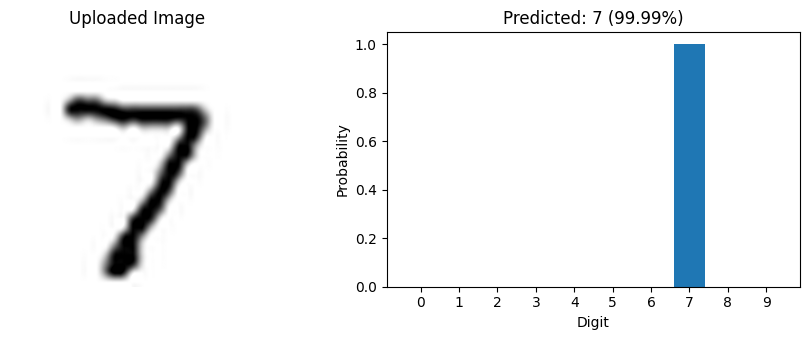

test2_rotated_shifted_digit_3.png


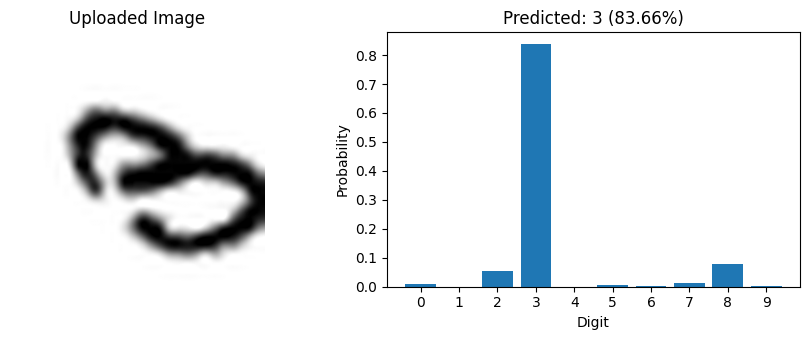

test3_ambiguous_true3_pred2.png


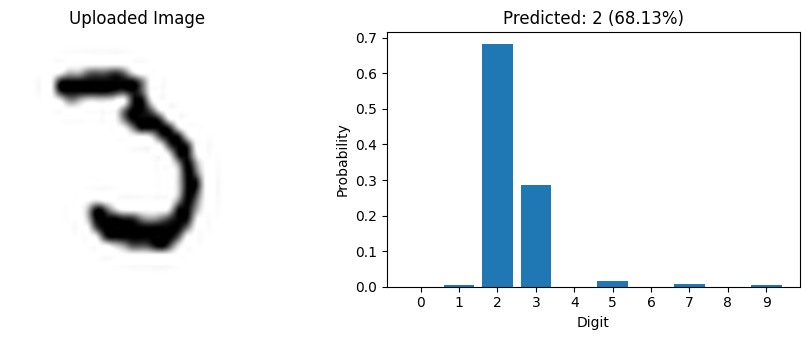

In [ ]:
from PIL import ImageOps

def predict_file(path):
    img = Image.open(path).convert("L")
    if np.array(img).mean() > 127:
        img = ImageOps.invert(img)
    img = ImageOps.autocontrast(img).resize((28, 28))
    x = (np.array(img) / 255.0).astype("float32").reshape(1, 28, 28, 1)
    p = model.predict(x, verbose=0)[0]

    fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
    ax[0].imshow(Image.open(path), cmap="gray"); ax[0].axis("off")
    ax[0].set_title("Uploaded Image")
    ax[1].bar(range(10), p); ax[1].set_xticks(range(10))
    ax[1].set_xlabel("Digit"); ax[1].set_ylabel("Probability")
    ax[1].set_title(f"Predicted: {p.argmax()} ({p.max()*100:.2f}%)")
    plt.tight_layout(); plt.show()

for f in sorted(os.listdir("sample_inputs")):
    print(f)
    predict_file(f"sample_inputs/{f}")

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
import pandas as pd
from PIL import Image, ImageOps

st.set_page_config(
    page_title="Handwritten Digit Recognition using ANN",
    page_icon="✍️",
    layout="wide"
)

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("digit_ann.keras")

model = load_model()

def preprocess(img):
    img = img.convert("L")
    if np.array(img).mean() > 127:
        img = ImageOps.invert(img)
    img = ImageOps.autocontrast(img)
    img = img.resize((28, 28))
    arr = np.array(img).astype("float32") / 255.0
    return arr.reshape(1, 28, 28, 1), img

st.title("✍️ Handwritten Digit Recognition using ANN")
st.markdown("Deep learning model trained with **image augmentation** on the MNIST dataset.")

col_left, col_right = st.columns([1, 1], gap="large")

with col_left:
    st.subheader("1. Upload Digit Image")
    uploaded = st.file_uploader("Upload an image (0-9)", type=["jpg", "jpeg", "png"])
    predict_btn = st.button("Predict Digit", type="primary", use_container_width=True)

with col_right:
    st.subheader("2. Prediction Results")
    if uploaded:
        raw_img = Image.open(uploaded)
        st.image(raw_img, caption="Uploaded Image", width=200)
    else:
        raw_img = None
        st.info("Upload a handwritten digit image to begin.")

    if predict_btn:
        if raw_img is None:
            st.warning("Please upload an image first.")
        else:
            with st.spinner("Recognizing digit..."):
                x, processed = preprocess(raw_img)
                probs = model.predict(x, verbose=0)[0]
                digit = int(np.argmax(probs))
                conf = float(probs[digit]) * 100

            st.write(f"### 🔢 Predicted Digit: **{digit}**")
            m1, m2 = st.columns(2)
            m1.metric("Predicted Class", str(digit))
            m2.metric("Confidence", f"{conf:.2f}%")
            st.image(processed.resize((112, 112)), caption="Model Input (28x28)")

            st.write("---")
            st.write("#### Class-wise Probability")
            st.bar_chart(pd.DataFrame({"Probability": probs}, index=range(10)))

Writing app.py


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!nohup streamlit run app.py --server.port 8501 --server.headless true > st.log 2>&1 &
!nohup ./cloudflared tunnel --url http://localhost:8501 > cf.log 2>&1 &
!sleep 10 && grep -o "https://[-a-z0-9]*\.trycloudflare\.com" cf.log | head -1

https://hear-aka-outcome-particles.trycloudflare.com
